# Импорт

In [ ]:
!apt-get install -qq -y quantum-espresso
!pip install -q ase

In [ ]:
!pip show ase | grep Version

Version: 3.28.0


In [100]:
import os
import tarfile
import ase.io
from ase import Atoms

import matplotlib.pyplot as plt
from ase.visualize.plot import plot_atoms
from ase.visualize import view

from ase.calculators.espresso import Espresso, EspressoProfile

# Структуры

## CIF  
> Метастабильная высокотемпературная фаза Ni₃Al, кристаллизующаяся в кубической сингонии по структурному типу α‑BiF₃ (в отличие от стабильной при комнатной температуре γ′-фазы со структурой Cu₃Au). Пространственная группа **Fm 3 m** (№ 225). Параметр решётки **a = 5.60378 Å**, объём ячейки ≈ **175.9 Å³**. Атомы алюминия занимают позиции **4a** (0,0,0) и трансляционно эквивалентные (0,½,½), (½,0,½), (½,½,0); двенадцать атомов никеля находятся в позициях **12c** с координатами (¼,¼,¼) и симметрийно порождёнными (¼,¾,¾), (¾,¼,¾), (¾,¾,¼) и т. д. Число формульных единиц Z = 4 (всего 16 атомов на ячейку: 4 Al + 12 Ni).

Источник: https://next-gen.materialsproject.org/materials/mp-672232/  

In [98]:
ni3al = ase.io.read("./CIF_Ni3Al/AlNi3.cif")
view(ni3al, viewer='x3d')

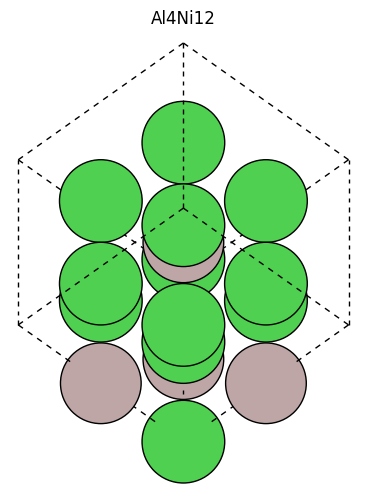

In [99]:
fig, ax = plt.subplots(figsize=(6, 6))
plot_atoms(ni3al, ax, radii=0.8, rotation=('45x,45y,90z'))
ax.set_title(ni3al.get_chemical_formula())
ax.set_axis_off()
plt.show()

In [ ]:
a_Ni = 3.52
ni_fcc = Atoms("Ni4", positions=[(0,0,0), (0.5,0.5,0), (0.5,0,0.5), (0,0.5,0.5)],
               cell=[[a_Ni,0,0], [0,a_Ni,0], [0,0,a_Ni]])

a_Al = 4.05
al_fcc = Atoms("Al4", positions=[(0,0,0), (0.5,0.5,0), (0.5,0,0.5), (0,0.5,0.5)],
               cell=[[a_Al,0,0], [0,a_Al,0], [0,0,a_Al]])

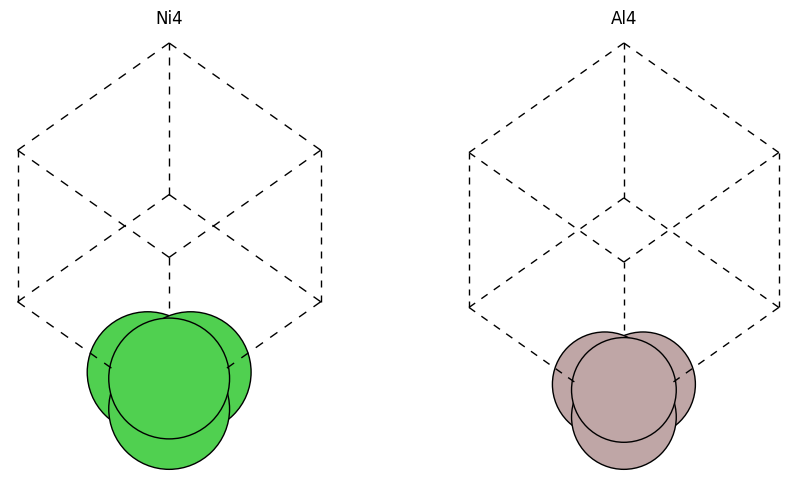

In [97]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

plot_atoms(ni_fcc, ax1, radii=0.8, rotation=('45x,45y,90z'))
ax1.set_title(ni_fcc.get_chemical_formula())
ax1.set_axis_off()

plot_atoms(al_fcc, ax2, radii=0.8, rotation=('45x,45y,90z'))
ax2.set_title(al_fcc.get_chemical_formula())
ax2.set_axis_off()

plt.tight_layout()
plt.show()

## Псевдопотенциалы

* UPF version=`2.0.1`

> Оба потенциала сгенерированы программой ONCVPSP v3.3.0 (D. R. Hamann) в полностью релятивистском режиме. Они являются норм-сохраняющими (NC) и включают нелинейную коррекцию остовного заряда (NLCC). В качестве обменно-корреляционного функционала использован PBE.

Источник: https://www.pseudo-dojo.org/
1. Type: NC FR (ONCVPSP v0.4)
2. XC: PBE
3. Accuracy: standart
4. Format: UPF.


In [ ]:
pseudo_dir = "./pseudo_Ni3Al"
pseudopotentials = {'Ni': 'Ni.upf', 'Al': 'Al.upf'}

# Параметры расчёта

In [ ]:
ecutwfc = 60
ecutrho = 480
degauss = 0.015
conv_thr = 1e-5

input_data = {
    'system': {
        'ecutwfc': ecutwfc,
        'ecutrho': ecutrho,
        'smearing': 'methfessel-paxton',
        'degauss': degauss,
    },
    'electrons': {
        'conv_thr': conv_thr,
        'mixing_mode': 'local-TF',
        'mixing_beta': 0.7,
        'mixing_ndim': 8,
        'diagonalization': 'david',
        'diago_david_ndim': 6,
    }
}

# Функция расчёта

In [ ]:
def calc_energy(structure, prefix, kpts):

    outdir = f"./tmp_{prefix}"
    os.makedirs(outdir, exist_ok=True)

    calc = Espresso(
        profile=EspressoProfile(command='pw.x', pseudo_dir=pseudo_dir),
        cmdline=['-npool', '4'],
        prefix=prefix,
        pseudopotentials=pseudopotentials,
        kpts=kpts,
        input_data=input_data,
        outdir=outdir
    )

    structure.calc = calc
    return structure.get_potential_energy()

# Расчёт энергий

Если за эталон взять расчёт чистого Ni (a=3.52 Å, сетка **8×8×8**), то эквивалентная плотность k‑точек требует пропорционального увеличения числа точек с ростом параметра ячейки:

$ Ni: a = 3.52 Å → N = 8 $

$ Al: a = 4.05 Å → N = 8 \times \frac{4.05}{3.52} \approx 9.2 \rightarrow \mathbf{9\times9\times9} $

$ Ni₃Al: a = 5.60 Å → N = 8 \times \frac{5.60}{3.52} \approx 12.7 \rightarrow \mathbf{13\times13\times13} $

In [ ]:
kpts_Ni = (8, 8, 8)
kpts_Al = (9, 9, 9)
kpts_Ni3Al = (13, 13, 13)

In [ ]:
E_Ni3Al = calc_energy(ni3al, "Ni3Al", kpts_Ni3Al)
E_Ni    = calc_energy(ni_fcc, "Ni", kpts_Ni)
E_Al    = calc_energy(al_fcc, "Al", kpts_Al)

In [ ]:
print(f"E(Ni3Al) = {E_Ni3Al:.6f}")
print(f"E(Ni)    = {E_Ni:.6f}")
print(f"E(Al)    = {E_Al:.6f}")

E(Ni3Al) = -54978.474984
E(Ni)    = -15778.924882
E(Al)    = 228.037289


# Архивация расчетов

In [ ]:
folders = ['tmp_Ni3Al', 'tmp_Ni', 'tmp_Al']

for folder in folders:
    if os.path.isdir(folder):
        archive_name = f"{folder}.tar.gz"
        with tarfile.open(archive_name, "w:gz") as tar:
            tar.add(folder, arcname=os.path.basename(folder))